In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Load market data for each symbol (example with 7 symbols)
symbols = ['2yr', '3yr', '5yr', '7yr', '10yr', '20yr', '30yr']
market_data = {}
for symbol in symbols:
    market_data[symbol] = pd.read_csv(f'{symbol}_combined_result.csv')

# Load trading data (with mixed symbols)
trading_data = pd.read_parquet('merged_r8fin_trades.parquet')


KeyboardInterrupt



In [10]:
# Group by 'parentcorrelationorderid' and 'syntheticcontractidentifier' to identify multi-leg trades
multi_leg_groups = trading_data.groupby(['parentcorrelationorderid', 'syntheticcontractidentifier'])

# Count the number of unique 'recapid' in each group to determine the number of legs
multi_leg_counts = multi_leg_groups['recapid'].nunique().reset_index(name='num_legs')

# Filter to keep only the groups that have more than 1 leg (multi-leg trades)
multi_leg_counts_filtered = multi_leg_counts[multi_leg_counts['num_legs'] > 1]

# Merge multi-leg information back to the original data
trading_data_with_legs = pd.merge(trading_data, multi_leg_counts_filtered, on=['parentcorrelationorderid', 'syntheticcontractidentifier'], how='inner')

# Extract instruments for multi-leg trades
multi_leg_instruments = trading_data_with_legs.groupby(['parentcorrelationorderid', 'syntheticcontractidentifier']).agg(
    instruments=('instrument', lambda x: list(x) if len(x) > 1 else [x.iloc[0]])
).reset_index()

# Merge instruments information back to the original data
trading_data_with_legs = pd.merge(trading_data_with_legs, multi_leg_instruments, on=['parentcorrelationorderid', 'syntheticcontractidentifier'], how='left')


In [15]:
# Define a function to extract specific leg instruments
def extract_leg(instruments_list, leg_index):
    try:
        return instruments_list[leg_index]
    except IndexError:
        return None

# Generate summary table for multi-leg trades
summary_table = trading_data_with_legs.groupby(['syntheticcontractidentifier']).agg(
    cash_vs_future=('security_type', lambda x: 'Cash' if (x == 'Cash').all() else 'Future'),
    first_leg_instrument=('instruments', lambda x: extract_leg(x.iloc[0], 0)),
    second_leg_instrument=('instruments', lambda x: extract_leg(x.iloc[0], 1)),
    third_leg_instrument=('instruments', lambda x: extract_leg(x.iloc[0], 2)),
    num_trades=('recapid', 'count'),
    market_value=('quantity', 'sum'),
    num_legs=('num_legs', 'max')
).reset_index()

# Calculate percentage columns
total_trades = summary_table['num_trades'].sum()
total_market_value = summary_table['market_value'].sum()
summary_table['% of All number of Trades'] = (summary_table['num_trades'] / total_trades) * 100
summary_table['% of Total Market Value of All Trades'] = (summary_table['market_value'] / total_market_value) * 100

# Filter to keep only multi-leg trades
summary_table = summary_table[summary_table['num_legs'] > 1]

# Ensure third_leg_instrument is set to None for trades with only two legs
summary_table.loc[summary_table['num_legs'] == 2, 'third_leg_instrument'] = None

In [17]:
summary_table['num_legs'].unique()

array([ 2,  3,  5, 10,  8,  4])

In [18]:
summary_table

,syntheticcontractidentifier,cash_vs_future,first_leg_instrument,second_leg_instrument,third_leg_instrument,num_trades,market_value,num_legs,% of All number of Trades,% of Total Market Value of All Trades
0,SC03102523152211117,Future,CT5-CT10 (Y),CT5-CT10 (Y),None,46,65.0,2,0.048373,0.004388
1,SC04020801462211100,Future,CT10-CT30 (Y),CT10-CT30 (Y),None,11,15.0,2,0.011568,0.001013
2,SC04112623232311291,Future,CT2-CT10 (Y),CT2-CT10 (Y),None,17,32.0,2,0.017877,0.002160
3,SC07051223132211100,Future,CT10-CT30 (Y),CT10-CT30 (Y),None,38,51.0,2,0.039960,0.003443
4,SC08041901112072311126,Future,CT5-CT30 (Y),CT5-CT30 (Y),None,74,134.0,2,0.077818,0.009046
...,...,...,...,...,...,...,...,...,...,...
190,SC10102322114925845504,Future,CT10-SFR 2Y BUNDLE Z4 (Y),CT10-SFR 2Y BUNDLE Z4 (Y),None,117,611.0,2,0.123036,0.041246
191,SC10102323464375647174,Future,FVROLL 5.1% TSFR SER E/L (4.25 2/29 4.5 5/29),FVROLL 5.1% TSFR SER E/L (4.25 2/29 4.5 5/29),None,83,329.0,2,0.087282,0.022209
192,SC10102422145483745519,Future,SFR 2Y BUNDLE Z4-CT5-CT10 (Y),SFR 2Y BUNDLE Z4-CT5-CT10 (Y),None,121,147.0,2,0.127243,0.009923
193,SC10102909340048647188,Future,DU ROLL 12.0 + 0.7% TED ER,DU ROLL 12.0 + 0.7% TED ER,None,131,382.0,2,0.137758,0.025787


In [19]:
# Save the summary table to a CSV file
summary_table.to_csv('multi_leg_trades_summary_table.csv', index=False)

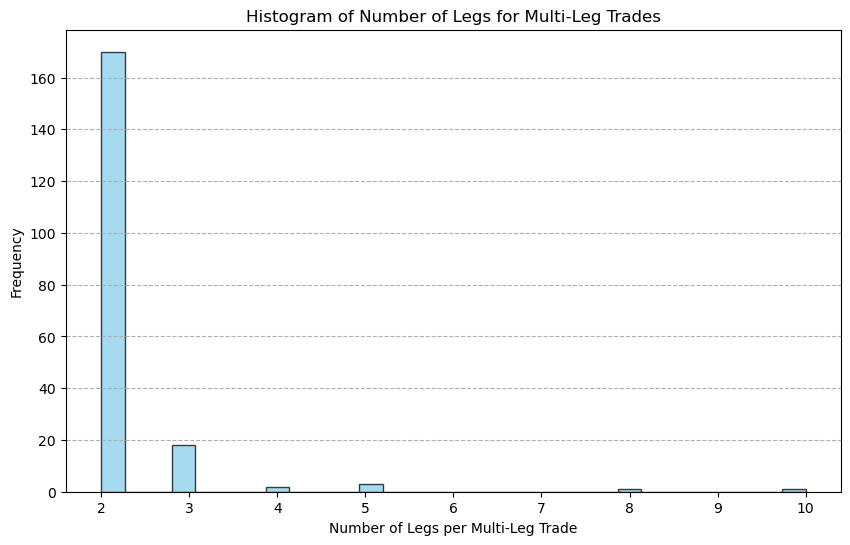

In [28]:
# Plot histogram of number of legs for multi-leg trades
plt.figure(figsize=(10, 6))
plt.hist(summary_table['num_legs'], bins=30, alpha=0.75, edgecolor='black', color='skyblue')
#sns.histplot(summary_table['num_legs'], bins=30, kde=True, color='skyblue')
plt.xlabel('Number of Legs per Multi-Leg Trade')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Legs for Multi-Leg Trades')
plt.grid(axis='y', linestyle='--')
plt.show()

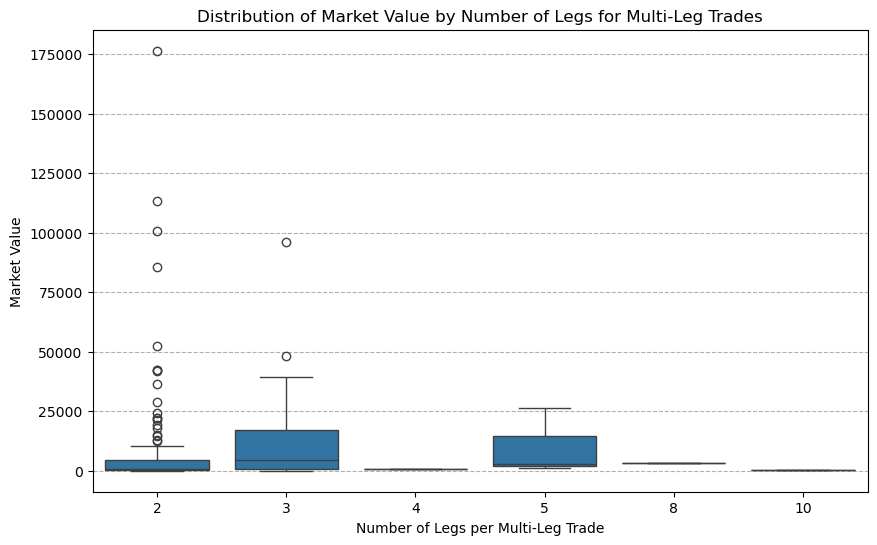

In [24]:
# Plot the distribution of market value for multi-leg trades
plt.figure(figsize=(10, 6))
sns.boxplot(data=summary_table, x='num_legs', y='market_value')
plt.xlabel('Number of Legs per Multi-Leg Trade')
plt.ylabel('Market Value')
plt.title('Distribution of Market Value by Number of Legs for Multi-Leg Trades')
plt.grid(axis='y', linestyle='--')
plt.show()

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_12488/4205596965.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_contracts, x='syntheticcontractidentifier', y='num_trades', palette='viridis')


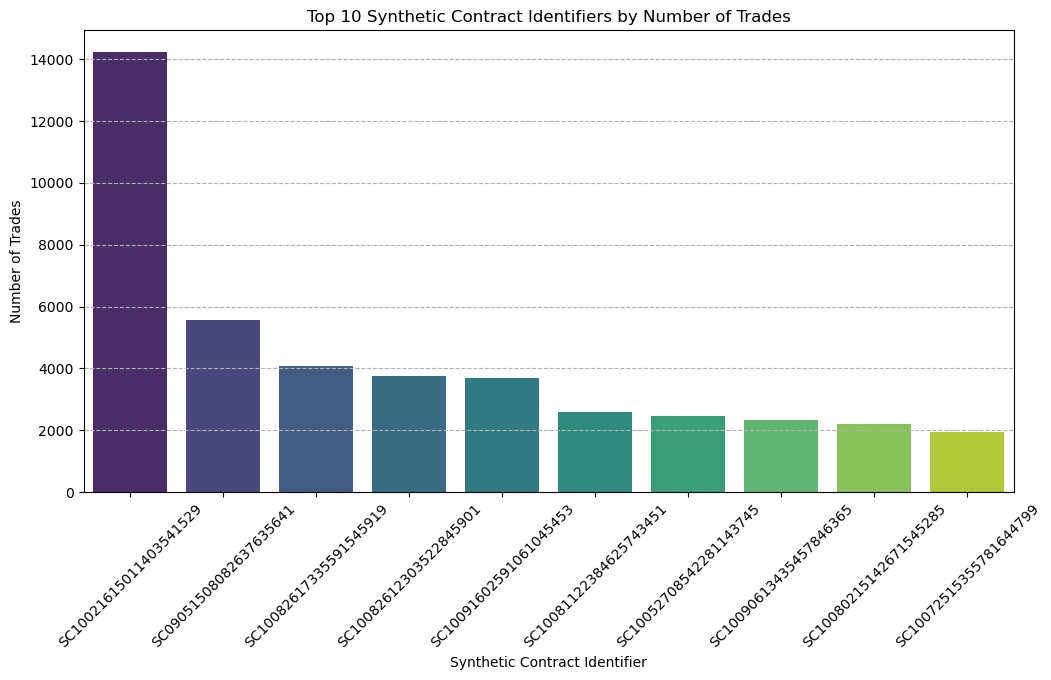

In [27]:
# Plot a bar chart of the top 10 synthetic contract identifiers by number of trades
top_10_contracts = summary_table.nlargest(10, 'num_trades')
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_contracts, x='syntheticcontractidentifier', y='num_trades', palette='viridis')
plt.xlabel('Synthetic Contract Identifier')
plt.ylabel('Number of Trades')
plt.title('Top 10 Synthetic Contract Identifiers by Number of Trades')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()